## 1. Business Understanding

### 1.1. Business Problem

Employee attrition is a major challenge for organizations, as high turnover leads to increased recruitment and training costs, loss of organizational knowledge, and reduced productivity. The Human Resources department wants to understand the key factors associated with employee attrition in order to improve employee retention and support data-driven decision-making.

### 1.2. Project Objective

The objective of this project is to analyze employee data to identify the main factors influencing attrition and provide actionable recommendations that can help reduce employee turnover.

### 1.3. Business Objectives

- Measure the overall employee attrition rate.
- Identify departments and job roles with the highest attrition.
- Analyze the relationship between employee demographics and attrition.
- Evaluate the impact of factors such as overtime, income, job satisfaction, and work-life balance on employee turnover.
- Build an interactive dashboard to support HR decision-making.

### 1.4. Key Business Questions

1. What is the overall employee attrition rate?
2. Which departments and job roles experience the highest turnover?
3. Does employee age influence attrition?
4. Is there a relationship between monthly income and attrition?
5. How does overtime affect employee turnover?
6. Does job satisfaction influence the likelihood of leaving the company?
7. How long do employees typically stay before leaving?
8. Does the distance from home affect attrition?
9. What actions can HR take to improve employee retention?

## 2. Data Understanding

### 2.1. Dataset Overview

The dataset contains employee demographic information, job-related attributes, compensation details, and satisfaction metrics. It also includes an `Attrition` variable indicating whether an employee has left the company, making it suitable for analyzing the factors associated with employee turnover.

In this section, we will explore the dataset structure, identify data types, detect potential data quality issues, and gain an initial understanding of the available variables before performing any data cleaning or analysis.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [62]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

#### First Look at the Dataset

Display the first five rows to gain an initial understanding of the dataset structure and verify that it has been loaded correctly.

In [63]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### 2.3. Dataset Dimensions

Determine the number of observations and variables contained in the dataset.

In [64]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1470
Columns: 35


#### Initial Observations

The dataset contains **1,470 employee records** and **35 variables**, providing demographic, employment, compensation, and satisfaction information for each employee.

#### Dataset Information

Review the dataset structure, data types, and non-null values for each variable.

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### Statistical Summary

Generate descriptive statistics for all numerical variables to better understand their distributions and identify potential anomalies.

In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


### Categorical Variables

Summarize the categorical variables to identify the number of unique categories, the most frequent values, and their frequencies.

In [67]:
df.describe(include="object").T

/tmp/ipykernel_3659/1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


### Missing Values

Check whether the dataset contains missing values that may require data cleaning.

In [68]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Duplicate Records

Verify whether duplicate observations exist in the dataset.

In [69]:
df.duplicated().sum()

np.int64(0)

### Unique Values

Count the number of unique values for each variable to identify columns with little or no variability.

In [70]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

### Variable Classification

Separate the dataset into numerical and categorical variables for future analysis.

In [71]:
str_type = df.select_dtypes(include="object").columns.to_list()
num_type = df.select_dtypes(include=["int64", "float64"]).columns.to_list()

print("Categorical Variables: ")
print(str_type)

print("\nNumerical Variables")
print(num_type)

Categorical Variables: 
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical Variables
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


/tmp/ipykernel_3659/3845330465.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_type = df.select_dtypes(include="object").columns.to_list()


### Initial Findings

- The dataset contains **1,470 employee records** and **35 variables**.
- No missing values were detected.
- No duplicate records were identified.
- The dataset includes a mix of numerical and categorical variables, giving us enough information to explore employee demographics, job characteristics, and factors that may be related to attrition
- Several variables appear to contain only a single unique value (e.g., `EmployeeCount`, `Over18`, and `StandardHours`), suggesting they may not provide analytical value.
- Overall, the dataset looks clean. There are no missing values or duplicate records, but a few columns appear to contain the same value for every employee. We'll take a closer look at those during the cleaning stage.

## 3. Data Cleaning

### 3.1. Overview

Now that we have a good understanding of the dataset, the next step is to prepare it for analysis.

Although the dataset is already well organized, it's still worth checking for potential issues such as missing values, duplicate records, inconsistent categories, and variables that don't add useful information. Making these checks now helps ensure the analysis is based on reliable data.

In [72]:
df_clean = df.copy()

### 3.2. Missing Values

Before making any changes, let's confirm whether the dataset contains missing values.

In [73]:
missing_values = df_clean.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

**Observation**

No missing values were found, so no imputation or row removal is required.

### 3.3. Duplicate Records

Next, we'll check for duplicate rows to make sure each employee appears only once in the dataset.

In [74]:
duplicates_values = df_clean.duplicated().sum()
print(f" Duplicates: {duplicates_values}")

 Duplicates: 0


**Observation**

No duplicate records were found.

### 3.4. Constant Columns

These variables contain the same value for every employee. Since they don't provide any variability, they won't contribute to the analysis and can be safely removed.

In [75]:
constant_columns = [
    column 
    for column in df.columns
    if df_clean[column].nunique() == 1

]

constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

In [76]:
for column in constant_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts())


EmployeeCount
EmployeeCount
1    1470
Name: count, dtype: int64

Over18
Over18
Y    1470
Name: count, dtype: int64

StandardHours
StandardHours
80    1470
Name: count, dtype: int64


In [77]:
df_clean.drop(columns=constant_columns, inplace=True)

df_clean.shape

(1470, 32)

**Observation**

The constant columns were removed because they don't provide any information that helps explain employee attrition.

In [78]:
df_clean.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrent

In [79]:
categorical_columns = df_clean.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n")
    print(df_clean[column].value_counts())



Attrition
No     1233
Yes     237
Name: count, dtype: int64


BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64


Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64


Gender
Male      882
Female    588
Name: count, dtype: int64


JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64


OverTime
No  

/tmp/ipykernel_3659/806169533.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(include="object").columns


In [80]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0


In [81]:
df_clean.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrent

In [82]:
df_clean.to_csv("../data/processed/hr_employee_attrition_clean.csv", index=False)

#### 3.5. Data Cleaning Summary

The dataset required very little cleaning. No missing values or duplicate records were found, and the data types were already appropriate for analysis.

The only changes made were the removal of a few constant columns (`EmployeeCount`, `Over18`, and `StandardHours`), as they contained the same value for every employee and did not provide useful information.

With these adjustments, the dataset is clean, consistent, and ready for exploratory data analysis.

## 4. Exploratory Data Analysis With Python

### 4.1. Introduction

With the dataset cleaned and ready, we can start exploring the factors that may be related to employee attrition.

The goal of this analysis is to identify patterns, compare different employee groups, and uncover insights that can help explain why employees leave the company.

### 4.2. Overall Attrition Rate
#### Business Question

What percentage of employees left the company?

In [83]:
attrition_counts = (
    df_clean["Attrition"].value_counts()
)

attrition_counts

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [84]:
attrition_rate = (
    df_clean["Attrition"].value_counts(normalize=True).mul(100).round(2)
)
attrition_rate

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

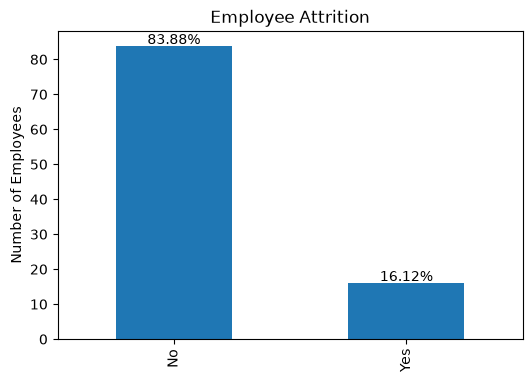

In [85]:
attrition_rate.plot(
    kind="bar", 
    figsize=(6, 4)
)

for i, value in enumerate(attrition_rate):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.title("Employee Attrition")
plt.xlabel("")
plt.ylabel("Number of Employees")
plt.show()

#### Insight

About 16% of employees left the company, while nearly 84% remained. Although most employees stayed, understanding what distinguishes the employees who left will be the focus of the next analyses.

### 4.3. Attrition by Department

#### Business Question
Which departments experience the highest employee attrition?

In [86]:
attrition_dept = (
    df_clean.groupby("Department")["Attrition"].value_counts().unstack(fill_value=0)
)
attrition_dept.columns.name = None
attrition_dept

,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [87]:
attrition_dept["Attrition Rate (%)"] = (
    attrition_dept["Yes"]/attrition_dept.sum(axis=1)*100
).round(2)

attrition_dept = attrition_dept.sort_values(by="Attrition Rate (%)", ascending=False)
attrition_dept

,No,Yes,Attrition Rate (%)
Department,,,
Sales,354,92,20.63
Human Resources,51,12,19.05
Research & Development,828,133,13.84


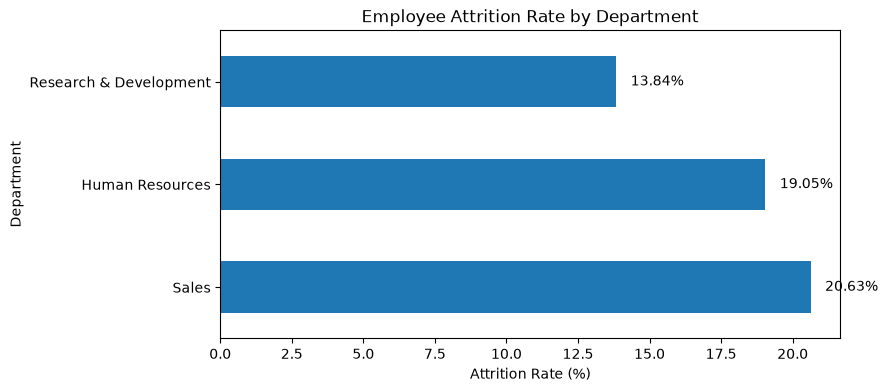

In [88]:
fig, ax = plt.subplots(figsize=(8,4))

attrition_dept["Attrition Rate (%)"].plot(
    kind="barh",
    ax=ax
)

for i, value in enumerate(attrition_dept["Attrition Rate (%)"]):
    plt.text(
        value + 0.5,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")
plt.show()

#### Insight

Sales has the highest attrition rate at **19.75%**, followed by Human Resources (**15.32%**). Research & Development has the lowest rate (**13.65%**), despite having the largest number of employees.

This suggests that turnover is not simply driven by department size. Other factors, such as workload, job role, or working conditions, may be contributing to the higher attrition observed in Sales.

### 4.4. Attrition by Job Role

#### Business Question

Which job roles experience the highest employee attrition?

In [89]:
jobrole_attrition = df_clean.groupby("JobRole")["Attrition"].value_counts().unstack(fill_value=0)

jobrole_attrition.columns.name = None
jobrole_attrition

,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


In [90]:
jobrole_attrition ["Attrition Rate (%)"]= (
    jobrole_attrition["Yes"]/jobrole_attrition.sum(axis=1)*100
).round(2)

jobrole_attrition = jobrole_attrition.sort_values(by="Attrition Rate (%)", ascending=False)
jobrole_attrition

,No,Yes,Attrition Rate (%)
JobRole,,,
Sales Representative,50,33,39.76
Laboratory Technician,197,62,23.94
Human Resources,40,12,23.08
Sales Executive,269,57,17.48
Research Scientist,245,47,16.10
Manufacturing Director,135,10,6.90
Healthcare Representative,122,9,6.87
Manager,97,5,4.90
Research Director,78,2,2.50


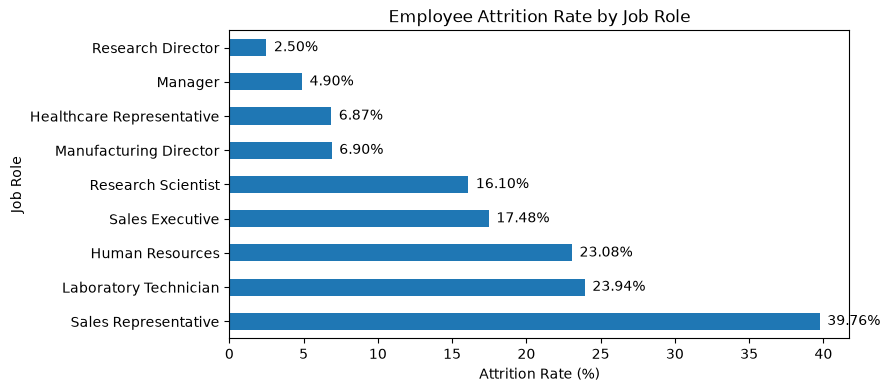

In [91]:
fig, ax = plt.subplots(figsize=(8, 4))
jobrole_attrition["Attrition Rate (%)"].plot(
    kind="barh",
    ax=ax
)

for i, value in enumerate(jobrole_attrition["Attrition Rate (%)"]):
    plt.text(
        value + 0.5, 
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.show()

In [92]:
jobrole_summary = (
    df_clean.groupby("JobRole")["Attrition"].value_counts().unstack(fill_value=0)
)
jobrole_summary.columns.name = None

jobrole_summary["Total Employees"] = (
    jobrole_summary["Yes"] + jobrole_summary["No"]
)

jobrole_summary["Attrition Rate (%)"] = (
    jobrole_summary["Yes"]/ jobrole_summary["Total Employees"]*100
).round(2)

jobrole_summary = (
    jobrole_summary.rename(columns={"Yes" : "Employees Left"}).sort_values(by="Attrition Rate (%)", ascending=False)
[["Total Employees", "Employees Left", "Attrition Rate (%)"]]
.sort_values(by="Attrition Rate (%)", ascending=False)
)

jobrole_summary


,Total Employees,Employees Left,Attrition Rate (%)
JobRole,,,
Sales Representative,83,33,39.76
Laboratory Technician,259,62,23.94
Human Resources,52,12,23.08
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Manufacturing Director,145,10,6.90
Healthcare Representative,131,9,6.87
Manager,102,5,4.90
Research Director,80,2,2.50


#### Observation

Attrition rates vary considerably across job roles. Sales Representatives have the highest attrition rate, followed by Laboratory Technicians and Human Resources.

Some of these roles also represent a large portion of the workforce, meaning they contribute a significant number of employee departures.

#### Key Insight

Employee turnover appears to be more concentrated in specific job roles than across departments. Sales Representatives stand out as the group with the highest attrition rate, making this role a strong candidate for further investigation.

This suggests that future retention strategies should focus on role-specific challenges rather than applying the same approach across the entire organization.

### 4.5. Attrition by Age
#### Business Question
Does employee age influence the likelihood of attrition?

In [93]:
df_clean["Age"].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

In [94]:
age_bins = [18, 25, 35, 45, 55, 65]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_attrition = (
    df_clean.groupby("AgeGroup", observed=False)["Attrition"].value_counts(normalize=True).mul(100).unstack()
).round(2)

age_attrition.columns.name = None
age_attrition = age_attrition[["Yes"]].rename(columns={"Yes" : "Attrition Rate (%)"}).sort_values(by="Attrition Rate (%)", ascending=False)
age_attrition 

,Attrition Rate (%)
AgeGroup,
18-25,35.77
26-35,19.14
56-65,17.02
46-55,11.50
36-45,9.19


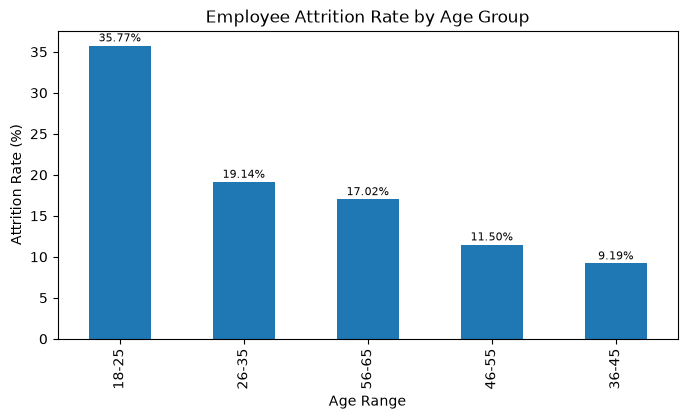

In [95]:
fig, ax = plt.subplots(figsize=(8, 4))
age_attrition["Attrition Rate (%)"].plot(
    kind="bar",
    ax=ax
)

for i, value in enumerate(age_attrition["Attrition Rate (%)"]):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=8
    )

plt.title("Employee Attrition Rate by Age Group")
plt.xlabel("Age Range")
plt.ylabel("Attrition Rate (%)")
plt.show()

#### Observation

Employees aged **18–25** show the highest attrition rate **(35.77%)**, well above the other age groups. Attrition is noticeably lower among employees between 26 and 55 years old, while the 56–65 group shows a small increase.

#### Insight

The results highlight a higher turnover among younger employees. Investing in career development, mentoring, and onboarding programs for early-career employees could help improve retention and reduce attrition within this group.

### 4.6. Attrition by Monthly Income
#### Business Question
Is there a relationship between monthly income and attrition?

In [96]:
df_clean["MonthlyIncome"].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

In [97]:
monthly_bins = [0, 5000, 10000, 15000, 20000]
monthly_labels = ["Low", "Medium", "Hight", "Very Hight"]

df_clean["MonthlyRange"] = pd.cut(
    df_clean["MonthlyIncome"], 
    bins=monthly_bins,
    labels=monthly_labels,
    include_lowest=True
)

monthly_attrition = (
    df_clean.groupby("MonthlyRange", observed=False)["Attrition"].value_counts(normalize=True).mul(100).unstack(fill_value=0)
).round(2)
monthly_attrition.columns.name = None
monthly_attrition = monthly_attrition[["Yes"]].rename(columns={"Yes" : "Attrition Rate (%)"})
monthly_attrition

,Attrition Rate (%)
MonthlyRange,
Low,21.76
Medium,11.14
Hight,13.51
Very Hight,3.76


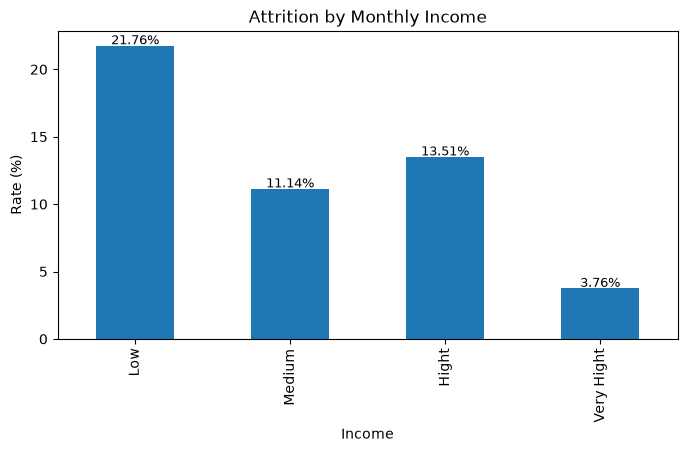

In [98]:
fig, ax = plt.subplots(figsize=(8, 4))
monthly_attrition["Attrition Rate (%)"].plot(
kind="bar",
ax=ax
)

for i, value in enumerate(monthly_attrition["Attrition Rate (%)"]):
    plt.text(
        i,
        value + 0.1,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.title("Attrition by Monthly Income")
plt.xlabel("Income")
plt.ylabel("Rate (%)")
plt.show()

#### Observation
Employees in the **Low** income group have the highest attrition rate. As monthly income increases, the attrition rate generally decreases, with employees in the **Very High** income group showing the lowest turnover.

#### Insight
The results suggest that employees with lower monthly income are more likely to leave the company. Reviewing compensation strategies and providing clear career growth opportunities for lower-income employees could help improve retention.

### 4.7. Attrition and Overtime
#### Business Question
How does overtime affect employee turnover?

In [99]:
df_clean["OverTime"].describe()

count     1470
unique       2
top         No
freq      1054
Name: OverTime, dtype: object

In [100]:
overtime_attrition = (
    df_clean.groupby("OverTime", observed=False)["Attrition"].value_counts(normalize=True).mul(100).unstack(fill_value=0)
).round(2)
overtime_attrition.columns.name = None
overtime_attrition = (
    overtime_attrition[["Yes"]].rename(columns={"Yes" : "Attrition Rate (%)"}).sort_values(by="Attrition Rate (%)", ascending=False)
)

overtime_attrition

,Attrition Rate (%)
OverTime,
Yes,30.53
No,10.44


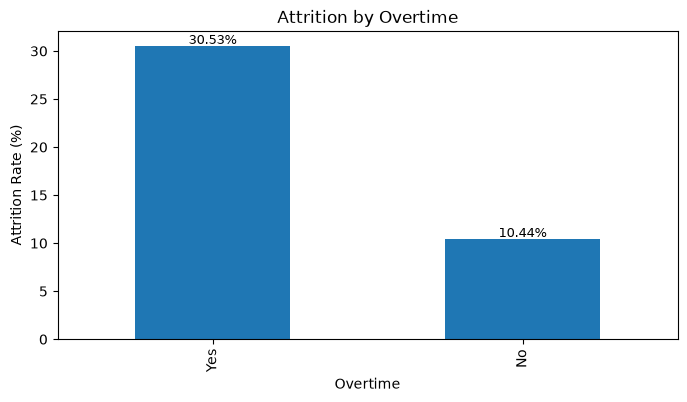

In [101]:
fig, ax = plt.subplots(figsize=(8, 4))
overtime_attrition["Attrition Rate (%)"].plot(
    kind="bar",
    ax=ax
)
for i, value in enumerate(overtime_attrition["Attrition Rate (%)"]):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )
plt.title("Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.show()

#### Observation
Employees who work overtime have an attrition rate of **30.53%**, nearly three times higher than employees who do not work overtime (**10.44%**).

#### Insight
The results suggest that overtime is associated with higher employee turnover. Monitoring overtime workload and promoting a healthier work-life balance may help improve employee retention.

### 4.8. Attrition by Job Satisfaction
#### Business Question
Does job satisfaction influence the likelihood of leaving the company?

In [102]:
df_clean["JobSatisfaction"].describe()

count    1470.000000
mean        2.728571
std         1.102846
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: JobSatisfaction, dtype: float64

In [103]:
jobsat_labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

order_satisfaction = ["Low", "Medium", "High", "Very High"]

df_clean["SatisfactionLevel"] = df_clean["JobSatisfaction"].map(jobsat_labels)
df_clean["SatisfactionLevel"] = pd.Categorical(
    df_clean["SatisfactionLevel"], 
    categories=order_satisfaction, 
    ordered=True
)
jobsat_attrition = (
    df_clean.groupby("SatisfactionLevel", observed=True)["Attrition"].value_counts(normalize=True).mul(100).unstack(fill_value=0)
).round(2)

jobsat_attrition.columns.name = None
jobsat_attrition = jobsat_attrition[["Yes"]].rename(columns={"Yes" : "Attrition Rate (%)"})
jobsat_attrition

,Attrition Rate (%)
SatisfactionLevel,
Low,22.84
Medium,16.43
High,16.52
Very High,11.33


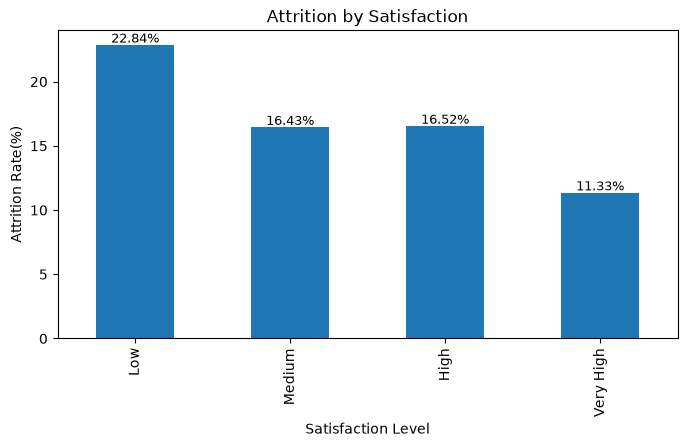

In [104]:
fig, ax = plt.subplots(figsize=(8, 4))
jobsat_attrition["Attrition Rate (%)"].plot(
kind="bar",
ax=ax
)

for i, value in enumerate(jobsat_attrition["Attrition Rate (%)"]):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.title("Attrition by Satisfaction")
plt.xlabel("Satisfaction Level")
plt.ylabel("Attrition Rate(%)")

plt.show()

#### Observation
Employees reporting low job satisfaction have the highest attrition rate (22.84%), while those with very high satisfaction have the lowest (11.33%). Attrition rates for employees with medium and high satisfaction are nearly identical, indicating that the most notable reduction in turnover occurs among employees with very high job satisfaction.

#### Insight
The findings suggest that employee satisfaction is associated with retention. Employees with very high job satisfaction are considerably less likely to leave the company, highlighting the importance of initiatives that improve workplace experience, recognition, and career development to strengthen long-term retention.

### 4.9. Attrition by Work-Life Balance
Does work-life balance influence employee attrition?

In [105]:
df_clean["WorkLifeBalance"].describe()

count    1470.000000
mean        2.761224
std         0.706476
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         4.000000
Name: WorkLifeBalance, dtype: float64

In [106]:
wlb_labels = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

order_wlb= ["Bad", "Good", "Better", "Best"]

df_clean["WorkLifeLevel"] = df_clean["WorkLifeBalance"].map(wlb_labels)
df_clean["WorkLifeLevel"] = pd.Categorical(
    df_clean["WorkLifeLevel"], 
    categories=order_wlb, 
    ordered=True
)
worklife_attrition = (
    df_clean.groupby("WorkLifeLevel", observed=True)["Attrition"].value_counts(normalize=True).mul(100).unstack(fill_value=0)
).round(2)

worklife_attrition.columns.name = None
worklife_attrition = worklife_attrition[["Yes"]].rename(columns={"Yes" : "Attrition Rate (%)"})
worklife_attrition

,Attrition Rate (%)
WorkLifeLevel,
Bad,31.25
Good,16.86
Better,14.22
Best,17.65


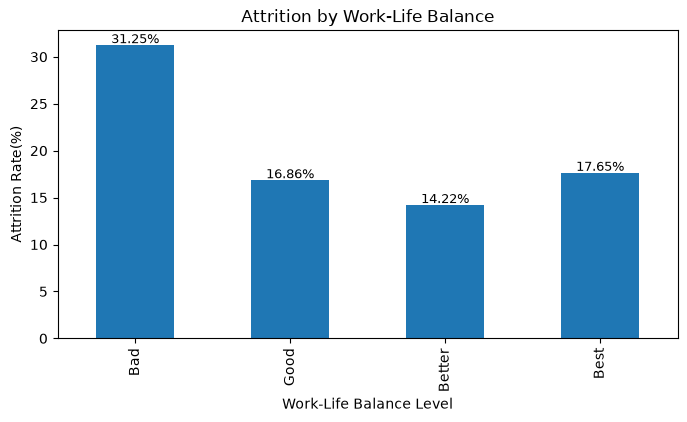

In [107]:
fig, ax = plt.subplots(figsize=(8, 4))
worklife_attrition["Attrition Rate (%)"].plot(
kind="bar",
ax=ax
)

for i, value in enumerate(worklife_attrition["Attrition Rate (%)"]):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.title("Attrition by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate(%)")

plt.show()

#### Observation
Employees reporting poor work-life balance have the highest attrition rate (**31.25%**). Attrition decreases substantially among employees with better work-life balance ratings, reaching its lowest level for those reporting a "Better" balance (**14.22%**). Although the attrition rate increases slightly for employees with the highest rating (**"Best"**), it remains considerably lower than for those with poor work-life balance.

#### Insight
The results suggest that work-life balance is associated with employee retention. Employees experiencing poor work-life balance are substantially more likely to leave the company, indicating that initiatives promoting flexible work arrangements, workload management, and employee well-being may help reduce turnover.

### 4.10. Attrition by Years at Company
#### Business Question
How long do employees typically stay before leaving the company?

In [108]:
df_clean["YearsAtCompany"].describe()

count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsAtCompany, dtype: float64

In [109]:
years_bins = [0, 5, 10, 20, 40]
year_labels = ["0 - 5", "6 - 10", "11 - 20", "21+"]

df_clean["YearsRange"] = pd.cut(
    df_clean["YearsAtCompany"], 
    bins=years_bins,
    labels=year_labels,
    include_lowest=True
)
years_attrition = (
    df_clean.groupby("YearsRange", observed=True)["Attrition"].value_counts(normalize=True).mul(100).unstack(fill_value=0)
).round(2)

years_attrition.columns.name = None
years_attrition = years_attrition[["Yes"]].rename(columns={"Yes" : "Attrition Rate (%)"})
years_attrition

,Attrition Rate (%)
YearsRange,
0 - 5,20.88
6 - 10,12.28
11 - 20,6.67
21+,12.12


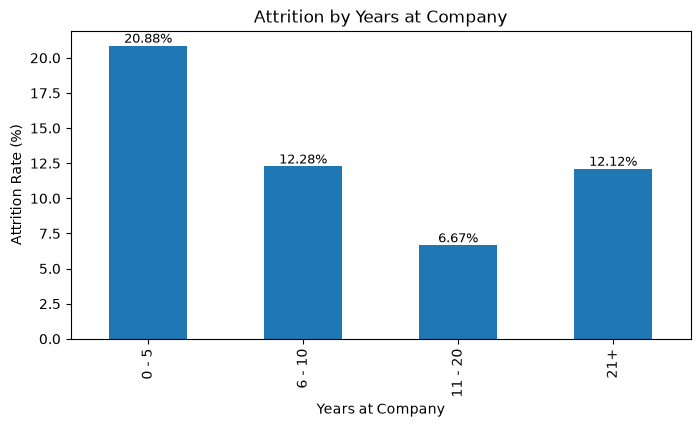

In [110]:
fig, ax = plt.subplots(figsize=(8, 4))
years_attrition["Attrition Rate (%)"].plot(
    kind="bar",
    ax=ax
)
for i, value in enumerate(years_attrition["Attrition Rate (%)"]):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center",
        fontsize=9.5
    )

plt.title("Attrition by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.show()

#### Observation
Employees with 0–5 years at the company have the highest attrition rate (**20.88%**). Attrition decreases as tenure increases, reaching its lowest level among employees with 11–20 years of service (**6.67%**). Although attrition rises slightly for employees with more than 20 years at the company (**12.12%**), it remains substantially lower than for newer employees.

#### Insight
The findings suggest that employee turnover is concentrated during the early years of employment. Strengthening onboarding, career development, and employee engagement initiatives during this period may improve retention and reduce early voluntary turnover.

### 4.11. Attrition by Distance From Home
Does the distance from home affect attrition?

In [111]:
df_clean["DistanceFromHome"].describe()

count    1470.000000
mean        9.192517
std         8.106864
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: DistanceFromHome, dtype: float64

In [112]:
distance_bins = [0, 5, 10, 20, 30]
distance_labels = ["Very Close", "Nearby", "Far", "So Far"]

df_clean["DistanceRange"] = pd.cut( 
    df_clean["DistanceFromHome"], 
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)
distance_attrition = (
    df_clean.groupby("DistanceRange", observed=True)["Attrition"].value_counts(normalize=True).mul(100).unstack(fill_value=0)
).round(2)

distance_attrition.columns.name = None
distance_attrition = distance_attrition[["Yes"]].rename(columns={"Yes" : "Attrition Rate (%)"})
distance_attrition

,Attrition Rate (%)
DistanceRange,
Very Close,13.77
Nearby,14.47
Far,20.00
So Far,22.06


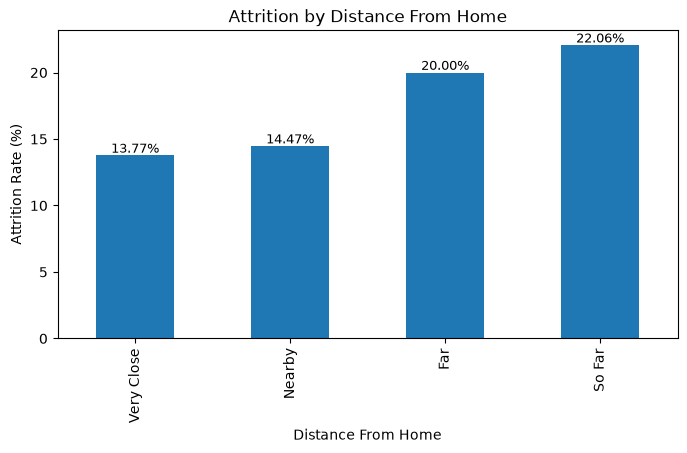

In [113]:
fig, ax = plt.subplots(figsize=(8, 4))
distance_attrition["Attrition Rate (%)"].plot(
    kind="bar",
    ax=ax
)
for i, value in enumerate(distance_attrition["Attrition Rate (%)"]):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center",
        fontsize=9.5
    )

plt.title("Attrition by Distance From Home")
plt.xlabel("Distance From Home")
plt.ylabel("Attrition Rate (%)")
plt.show()

#### Observation
Employees living closest to the workplace (0–5) have the lowest attrition rate (13.77%). Attrition remains relatively stable for employees in the 6–10 range (14.47%) but increases noticeably among those living farther away, reaching 20.00% for employees in the 11–20 range and 22.06% for those living more than 20 units from the workplace.

#### Insight
The findings suggest that commuting distance is associated with employee turnover. Employees living farther from the workplace are more likely to leave the company, indicating that flexible work arrangements, hybrid schedules, or location-based support initiatives could help improve retention among long-distance commuters.

### 4.12. Correlation Analysis
How are the numerical employee characteristics related to one another?

In [114]:
df_clean.select_dtypes(include="number").columns.tolist()

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [115]:
numerical_features = df_clean.select_dtypes(include="number").drop(
    columns=["EmployeeNumber"]
)

corr_matrix = numerical_features.corr()

corr_matrix

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.003634,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,-0.032182,0.038153,0.022704,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.040235,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.011111,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,0.037600,0.012594,-0.031701,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,-0.015297,0.022157,-0.009062,-0.002172,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,-0.016322,0.015012,-0.017205,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,0.039563,0.142501,-0.034730,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,0.000644,-0.055699,0.020002,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
MonthlyIncome,0.497855,0.007707,-0.017014,0.094961,-0.006259,-0.015794,-0.015271,0.950300,-0.007157,1.000000,0.034814,0.149515,-0.027269,-0.017120,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079


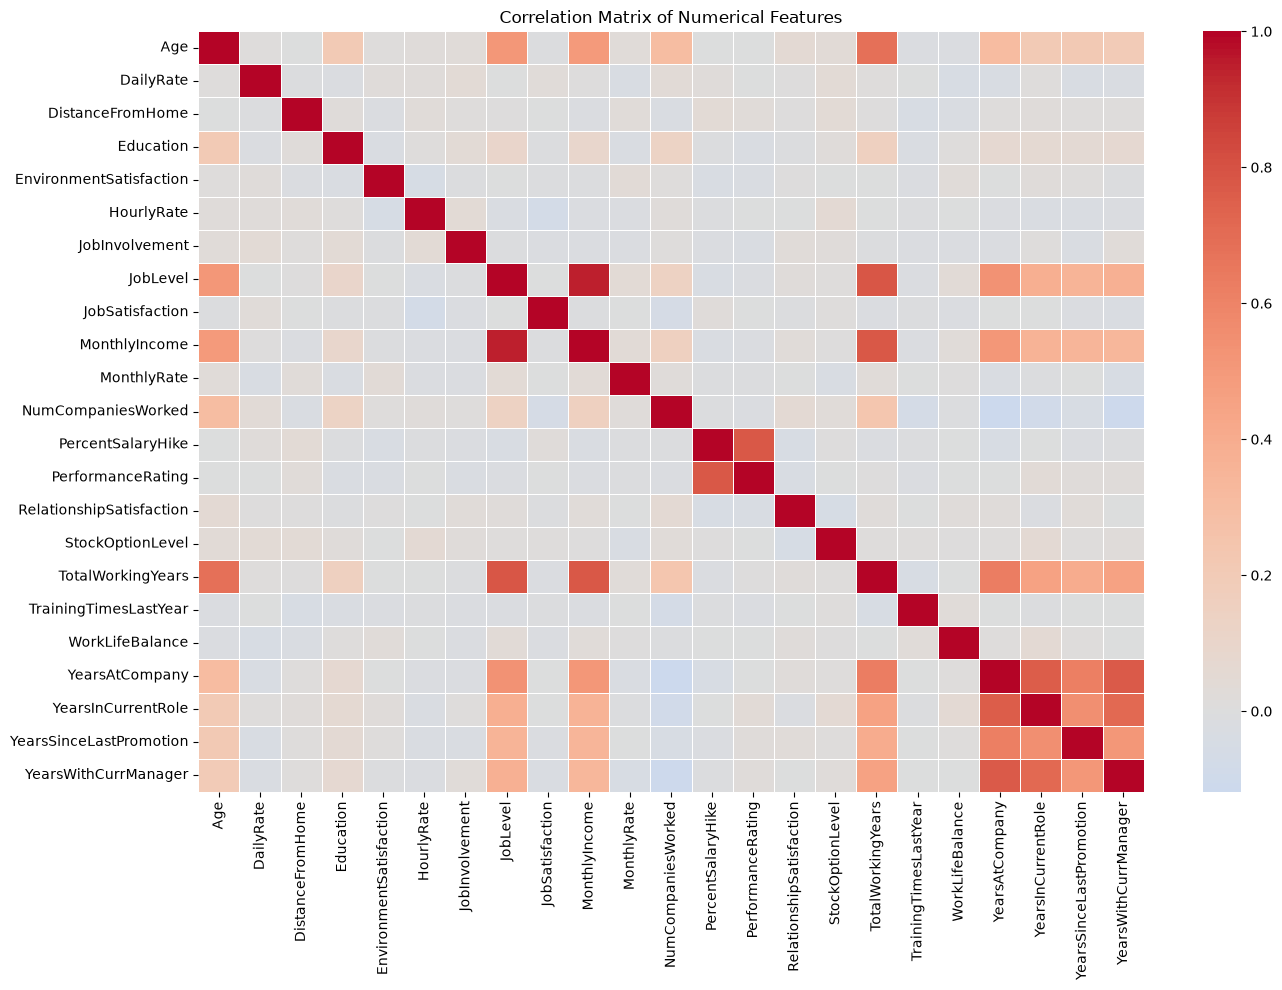

In [116]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [117]:
corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

corr_pairs["Absolute Correlation"] = corr_pairs["Correlation"].abs()

top_corr = (
    corr_pairs.sort_values(
        by="Absolute Correlation",
        ascending=False
    )
    .drop(columns="Absolute Correlation")
)

top_corr.head(15).reset_index(drop=True).style.format({"Correlation": "{:.3f}"})

,Feature 1,Feature 2,Correlation
0,JobLevel,MonthlyIncome,0.950
1,JobLevel,TotalWorkingYears,0.782
2,PercentSalaryHike,PerformanceRating,0.774
3,MonthlyIncome,TotalWorkingYears,0.773
4,YearsAtCompany,YearsWithCurrManager,0.769
5,YearsAtCompany,YearsInCurrentRole,0.759
6,YearsInCurrentRole,YearsWithCurrManager,0.714
7,Age,TotalWorkingYears,0.680
8,TotalWorkingYears,YearsAtCompany,0.628
9,YearsAtCompany,YearsSinceLastPromotion,0.618


#### Observation
The strongest correlations are mainly observed between variables related to employee experience, seniority, and compensation. Variables such as job level, monthly income, total working years, and years at the company show strong positive relationships.
Most variables present weak to moderate correlations, suggesting that the dataset does not contain extensive redundancy among features.

#### Insight
The correlation analysis highlights expected career progression patterns within the organization. Employees with higher job levels and longer professional experience tend to have higher income and greater tenure.
These relationships provide useful context for understanding employee characteristics, although correlation alone does not indicate that one variable causes another or directly explains employee attrition.


### 4.13. Key Findings & HR Recommendations
What actions can HR take to improve employee retention?

#### Key Findings
- The company has an overall attrition rate of approximately 16%, indicating that employee turnover is a relevant business challenge.
- Attrition is not evenly distributed across the organization. Certain departments and job roles experience considerably higher turnover than others.
- Younger employees are more likely to leave the company, while attrition decreases with age.
- Employees with lower monthly income show higher attrition rates than those with higher salaries.
- Employees who work overtime are significantly more likely to leave the organization.
- Lower job satisfaction is associated with substantially higher attrition.
- Most employees who leave the company do so during their first years of employment, suggesting that early retention is critical.
- Distance from home shows only a limited relationship with attrition compared to other factors.
- Employees combining multiple risk factors, such as overtime, low income, low job satisfaction, and short tenure, represent the highest-risk group for attrition.

#### HR Recommendations
Based on the findings, the following actions could help improve employee retention:

1. Monitor overtime levels and review workload distribution to reduce excessive workload and prevent employee burnout.
2. Strengthen onboarding and employee support programs, especially during the first years of employment when attrition risk is higher.
3. Review compensation strategies for lower-income employee groups to improve competitiveness and retention.
4. Implement regular employee satisfaction surveys to identify concerns related to engagement, motivation, and workplace experience.
5. Promote initiatives that support work-life balance, such as flexible work arrangements and employee well-being programs.
6. Develop targeted retention strategies for departments and job roles with higher attrition rates instead of applying a single approach across the organization.
7. Continue using HR analytics dashboards to monitor attrition patterns and evaluate the effectiveness of retention initiatives over time.

## 5. SQL Analysis

After completing the exploratory data analysis in Python, SQL is used to query the cleaned employee database and answer key business questions from a relational database perspective.
This section demonstrates the ability to retrieve, aggregate, filter, and analyze HR data using SQL. The queries focus on workforce composition, employee attrition, and other workforce metrics that support business decision-making.

### 5.1. Database Setup

The cleaned HR dataset was imported into a SQLite database named **hr_attrition.db**.
The database contains a single table:
- **employees**: stores demographic, job-related, compensation, and attrition information for 1,470 employees.
This database will be used throughout this section to perform business-oriented SQL analysis.

### 5.2. Business Queries
#### 5.2.1 Workforce Overview
**How many employees are included in the database?**
```sql
SELECT count(*) AS "total_employees" 
FROM "employees";
```
**Observation**
The database contains **1,470 employee records**, indicating that all employees were successfully imported into the SQLite database.

#### 5.2.2 Overall Attrition
**What is the overall employee attrition rate?**
```sql
SELECT
    Attrition,
    COUNT(*) AS Employees,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM employees), 2) AS AttritionRate
FROM employees
GROUP BY Attrition;
```
**Observation**
A total of **237 employees** left the company, representing an overall attrition rate of **16.12%**, while **83.88%** of employees remained with the organization.



#### 5.2.3. Attrition by Department
**Which departments have the highest employee attrition rate?**
```sql
SELECT "Department", count(*) AS "TotalEmployees",
SUM(CASE 
        WHEN "Attrition" = 'Yes' THEN 1 
        ELSE 0 END) AS "EmployeesLeft",
ROUND(SUM(CASE 
                WHEN "Attrition" = 'Yes' THEN 1 
                ELSE 0 END) * 100.0 / count(*), 2) AS "Attrition_Rate"
FROM "employees"
GROUP BY "Department"
ORDER BY "Attrition_Rate" DESC;
```
**Observation**
The **Sales** department has the highest attrition rate at **20.63%**, followed by **Human Resources** at **19.05%**. **Research & Development** has the largest workforce but the lowest attrition rate among the three departments.


#### 5.2.4. Attrition by Job Role
**Which job roles have the highest employee attrition rates?**
```sql
SELECT JobRole, count(*) AS TotalEmployees,
SUM(CASE
        WHEN Attrition = 'Yes' THEN 1
        ELSE 0 END) AS EmployeesLeft,
ROUND(SUM(CASE
        WHEN Attrition = 'Yes' THEN 1
        ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate"
FROM Employees
GROUP BY "JobRole"
ORDER BY "AttritionRate" DESC;
```
**Observation**
Attrition varies considerably across job roles. Sales Representatives have the highest attrition rate, while Research Directors show one of the lowest attrition rates.

#### 5.2.5. Attrition by Overtime
**How does overtime relate to employee attrition?**
```sql
SELECT "OverTime", count(*) AS "TotalEmployees",
SUM(CASE
        WHEN "Attrition" = 'Yes' THEN 1
        ELSE 0 END) AS "EmployeesLeft",
ROUND(SUM(CASE
                WHEN "Attrition" = 'Yes' THEN 1
                ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate"
FROM "employees"
GROUP BY "OverTime"
```
**Observation**
Employees who work overtime have a substantially higher attrition rate (**30.53%**) compared with employees who do not work overtime (**10.44%**).

#### 5.2.6. Attrition by Monthly Income
**How does monthly income relate to employee attrition?**
```sql
SELECT
CASE
    WHEN "MonthlyIncome" <= '5000' THEN 'Low'
    WHEN "MonthlyIncome" <= '10000' THEN 'Medium'
    WHEN "MonthlyIncome" <= '15000' THEN 'High'
    ELSE 'Very High'
END AS "IncomeLevel",
SUM(CASE
        WHEN "Attrition" = 'Yes' THEN 1
        ELSE 0 END) AS "EmployessLeft",
ROUND(SUM(CASE
                WHEN "Attrition" = 'Yes' THEN 1
                ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate"
FROM "employees"
GROUP BY "IncomeLevel"
ORDER BY "AttritionRate" DESC;
```
**Observation**
Attrition is highest among employees in the Low Income group (**21.76%**) and lowest among employees in the Very High Income group (**3.76%**). Overall, lower-income employees show substantially higher attrition rates than higher-income employees.

#### 5.2.7. Attrition by Job Satisfaction
**How does job satisfaction relate to employee attrition?**
```sql
SELECT
CASE
    WHEN "JobSatisfaction" = 1 THEN "Low"
    WHEN "JobSatisfaction" = 2 THEN "Medium"
    WHEN "JobSatisfaction" = 3 THEN "High"
    ELSE "Very High"
END AS "SatisfactionLevel",
count(*) AS "TotalEmployees",
SUM(CASE
        WHEN "Attrition" = 'Yes' THEN 1
        ELSE 0 END) AS "EmployeesLeft",
ROUND(SUM(CASE
                WHEN "Attrition" = 'Yes' THEN 1
                ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate"
FROM "employees"
GROUP BY "JobSatisfaction"
ORDER BY "AttritionRate" DESC;
```
**Observation**
Employees with Low Job Satisfaction have the highest attrition rate (**22.84%**), while employees with Very High Job Satisfaction have the lowest rate (**11.33%**). Attrition generally decreases as job satisfaction increases.

#### 5.2.8. Attrition by Work-Life Balance
**How does work-life balance relate to employee attrition?**
```sql
SELECT
CASE
    WHEN "WorkLifeBalance" = 1 THEN "Bad"
    WHEN "WorkLifeBalance" = 2 THEN "Medium"
    WHEN "WorkLifeBalance" = 3 THEN "Good"
    ELSE "Very Good"
END AS "WorkLifeLevel",
count(*) AS "TotalEmployees",
SUM(CASE
        WHEN "Attrition" = 'Yes' THEN 1
        ELSE 0 END) AS "EmployeesLeft",
ROUND(SUM(CASE
                WHEN "Attrition" = 'Yes' THEN 1
                ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate"
FROM "employees"
GROUP BY "WorkLifeLevel"
ORDER BY "WorkLifeLevel" ASC;
```
**Observation**
Employees with a Bad Work-Life Balance have the highest attrition rate (**31.25%**). Attrition is lower among employees with Good and Better work-life balance, while the Best category shows a slightly higher rate than the Better category.

#### 5.2.9. Attrition by Years at Company
**How does employee tenure relate to attrition?**
```sql
SELECT
CASE
    WHEN "YearsAtCompany" <= 5 THEN '0 - 5'
    WHEN "YearsAtCompany" <= 10 THEN '6 - 10'
    WHEN "YearsAtCompany" <= 20 THEN '11 - 20'
    ELSE '21+'
END AS "YearsRange",
count(*) AS "TotalEmployees",
SUM(CASE
        WHEN "Attrition" = 'Yes' THEN 1
        ELSE 0 END) AS "EmployeesLeft",
ROUND(SUM(CASE
                WHEN "Attrition" = 'Yes' THEN 1
                ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate"
FROM "employees"
GROUP BY "YearsRange"
ORDER BY "YearsAtCompany" ASC;
```
**Observation**
Attrition is highest among employees with **0–5 years at the company (20.88%)** and generally decreases as tenure increases. Employees with **11–20 years of tenure have the lowest attrition rate (6.67%)**, while the 21+ group shows a moderate increase to **12.12%**.

#### 5.2.10. Attrition by Distance From Home
**How does distance from home relate to employee attrition?**
```sql
SELECT
CASE
    WHEN "DistanceFromHome" <= 5 THEN 'Very Close'
    WHEN "DistanceFromHome" <= 10 THEN 'Nearby'
    WHEN "DistanceFromHome" <= 20 THEN 'Far'
    ELSE 'Very Far'
END AS "DistanceRange",
count(*) AS "TotalEmployees",
SUM(CASE
        WHEN "Attrition" =  'Yes' THEN 1
        ELSE 0 END) AS "EmployeesLeft",
ROUND(SUM(CASE
                WHEN "Attrition" = 'Yes' THEN 1
                ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate"
FROM "employees"
GROUP BY "DistanceRange"
ORDER BY "DistanceFromHome";
```
**Observation**
Attrition increases as distance from home increases. Employees living **21+ miles from the workplace have the highest attrition rate (22.06%)**, while employees living within **0–5 miles have the lowest rate (13.77%)**.

### 5.3. Advanced SQL Analysis
#### 5.3.1. Attrition Rate by Department and Job Role
**Which department and job role combinations have the highest attrition rates?**

```sql
SELECT "Department", "JobRole",
        count(*) AS "TotalEmployees",
        SUM(CASE
                WHEN "Attrition" = 'Yes' THEN 1
                ELSE 0 END) AS "EmployeesLeft",
        ROUND(SUM(CASE
                        WHEN "Attrition" = 'Yes' THEN 1
                        ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate"
FROM "employees"
GROUP BY "Department", "JobRole"
HAVING "TotalEmployees" >= 20
ORDER BY "AttritionRate" DESC;
´´´

**observation**
Sales Representatives have the highest attrition rate at 39.76%, followed by Laboratory Technicians at 23.94% and Human Resources employees at 23.08%. In contrast, managerial and senior roles show considerably lower attrition rates, with Research Directors having the lowest rate at 2.50%.

#### 5.3.2. High-Risk Employee Segments
Which employee segments combine multiple characteristics associated with higher attrition?
```sql
WITH "employees_risk" AS (
        SELECT
        "EmployeeNumber",
        "OverTime",
        "JobSatisfaction",
        "YearsAtCompany",
        "DistanceFromHome",
        CASE
            WHEN "OverTime" = 'Yes'
                AND "JobSatisfaction" <= 2
                AND "YearsAtCompany" <= 5
                AND "DistanceFromHome" >= 11
                THEN "High Risk"

            WHEN "OverTime" = 'Yes'
                AND (
                        "JobSatisfaction" <= 2
                        OR "YearsAtCompany" <= 5
                        OR "DistanceFromHome" >= 11
                        )
                THEN "Medium Risk"

                ELSE "Low Risk"
           END AS "RiskLevel"
        FROM "employees"
)

SELECT "RiskLevel",
        count(*) AS "TotalEmployees",
        SUM(CASE
                WHEN "Attrition" = 'Yes' THEN 1 ELSE 0
                END) AS "EmployeesLeft",
        ROUND(SUM(CASE
                       WHEN "Attrition" = 'Yes' THEN 1
                       ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate"
FROM "employees_risk" AS "s"
JOIN "employees" AS "e"
ON "s"."EmployeeNumber" = "e"."EmployeeNumber"
GROUP BY "RiskLevel"
ORDER BY "AttritionRate" DESC;
```

**Observation**
Employees classified as High Risk have the highest attrition rate at 62.50%, with 20 out of 32 employees leaving the company. Medium Risk employees show an attrition rate of 30.07%, while Low Risk employees have a substantially lower rate of 11.04%.


#### 5.3.3. Attrition Compared with the Company Average
***Which job roles have an attrition rate above the overall company average?***
```sql
SELECT "JobRole",
        count(*) AS "TotalEmployees",
        SUM(CASE
                 WHEN "Attrition" = 'Yes' THEN 1
                      ELSE 0 END) AS "EmployeesLeft",
        ROUND(SUM(
                  CASE
                       WHEN "Attrition" = 'Yes' THEN 1
                            ELSE 0 END) * 100.0 / count(*), 2) AS "AttritionRate",
        ROUND(SUM(
                   CASE
                        WHEN "Attrition" = 'Yes' THEN 1
                             ELSE 0 END) * 100.0 / count(*) -
                             (SELECT SUM(
                                         CASE
                                              WHEN "Attrition" = 'Yes' THEN 1
                                              ELSE 0 END) * 100.0 / count(*)
                              FROM "employees"), 2) AS "DifferenceFromAverage"
FROM "employees"
GROUP BY "JobRole"
HAVING COUNT(*) >= 20
ORDER BY "DifferenceFromAverage" DESC;
```
**Observation**
Sales Representatives have the largest positive difference from the company average, with an attrition rate 23.64 percentage points above the overall rate. Laboratory Technicians and Human Resources employees are also above average, while Research Scientists are almost exactly at the company average. Managerial and senior roles remain considerably below the overall attrition rate.


#### 5.3.4. Job Roles Ranked by Attrition
How do job roles rank based on their attrition rates?
```sql
WITH "jobrole_attrition" AS(
        SELECT "JobRole",
        count(*) AS "TotalEmployees",
        SUM(
            CASE
                WHEN "Attrition" = 'Yes' THEN 1
                ELSE 0
            END
        ) AS "EmployeesLeft",
        ROUND(
                SUM(
                        CASE
                            WHEN "Attrition" = 'Yes' THEN 1
                            ELSE 0
                        END
                ) * 100.0 / count(*), 2
        ) AS "AttritionRate"
FROM "employees"
GROUP BY "JobRole"
)

SELECT "JobRole",
"TotalEmployees",
"EmployeesLeft",
"AttritionRate",
RANK() OVER(
        ORDER BY "AttritionRate"
) AS "AttritionRank"
FROM "jobrole_attrition"
WHERE "TotalEmployees" >= 20
ORDER BY "AttrtionRank";
```
**Observation**
Sales Representative ranks first with the highest attrition rate at 39.76%, followed by Laboratory Technician at 23.94% and Human Resources at 23.08%. In contrast, Research Director ranks last with an attrition rate of 2.50%, while managerial roles also remain among the lowest-ranked position

#### 5.3.5. Attrition by Income Level Within Job Role
**How does attrition vary across income levels within different job roles?**
```sql
WITH "income_attrition" AS(
        SELECT
              "JobRole",
              "MonthlyIncome",
              "Attrition",
              CASE
                  WHEN "MonthlyIncome" <= 5000 THEN "Low"
                  WHEN "MonthlyIncome" <= 10000 THEN "Medium"
                  WHEN "MonthlyIncome" <= 15000 THEN "High"
                  ELSE "Very High"
              END AS "IncomeLevel"

        FROM "employees"
)

SELECT
    "JobRole",
    "IncomeLevel",
    count(*) AS "TotalEmployees",
    SUM(
        CASE
            WHEN "Attrition" = 'Yes' THEN 1
            ELSE 0
        END
    ) AS "EmployeesLeft",
    ROUND(
        SUM(
                CASE
                    WHEN "Attrition" = 'Yes' THEN 1
                    ELSE 0
                END
        ) * 100.0 / count(*), 2
    ) AS "AttritionRate"
FROM "income_attrition"
GROUP BY "JobRole", "IncomeLevel"
HAVING count(*) >= 10
ORDER BY "AttritionRate" DESC;
```
**Observation**
Attrition varies considerably across income levels within different job roles. The highest attrition is observed among lower-income employees in Sales Representative, Human Resources, and Laboratory Technician roles. However, the relationship is not consistent across all positions, as some higher-income groups also show relatively high attrition, particularly Sales Executives.

## 6. Power BI Dashboard
### Employee Attrition Dashboard
Interactive dashboard designed to monitor employee attrition and explore key factors associated with turnover, including department, job role, overtime, job satisfaction, and other employee characteristic

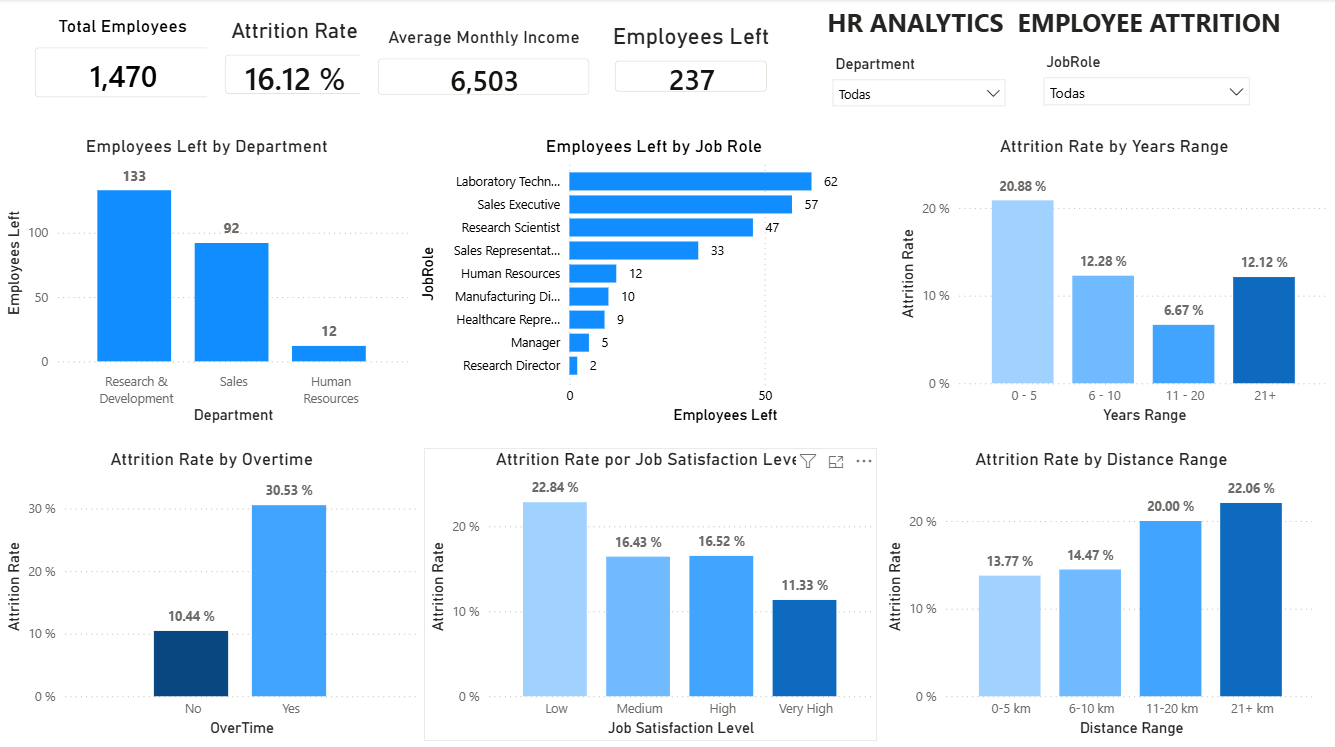

## 7. Business Insights & Recommendations
### 7.1. Key Business Insights

The analysis identified several factors that are consistently associated with higher employee attrition. The most relevant findings are summarized below:

#### 1. Overtime is strongly associated with higher attrition

Employees working overtime have a substantially higher attrition rate than those who do not work overtime.

- Overtime: **30.53%**
- No Overtime: **10.44%**

This suggests that workload and working hours may be important factors to consider when developing employee retention strategies.

#### 2. Attrition is higher among employees with shorter tenure

Employees with fewer years at the company show higher attrition rates, particularly during the first five years.

- 0–5 years: **20.88%**
- 6–10 years: **12.28%**
- 11–20 years: **6.67%**
- 21+ years: **12.12%**

The results highlight the importance of early-career retention strategies and employee development programs.

#### 3. Longer commuting distances are associated with higher attrition

Attrition increases among employees who live farther from the workplace.

- 0–5 miles: **13.77%**
- 6–10 miles: **14.47%**
- 11–20 miles: **20.00%**
- 21+ miles: **22.06%**

Longer commuting distances may represent an additional challenge for employee retention and should be considered when evaluating workforce needs.

#### 4. Lower job satisfaction is associated with higher attrition

Employees reporting lower job satisfaction have considerably higher attrition rates than employees with very high satisfaction.

- Low: **22.84%**
- Medium: **16.43%**
- High: **16.52%**
- Very High: **11.33%**

This indicates that improving employee satisfaction could be an important component of retention strategies.

#### 5. Poor work-life balance is associated with higher attrition

Employees reporting poor work-life balance have the highest attrition rate among the four categories.

- Bad: **31.25%**
- Good: **16.86%**
- Better: **14.22%**
- Best: **17.65%**

The results suggest that workload management and work-life balance should be considered when addressing employee retention.

#### Overall Insight

Overall, higher attrition is associated with a combination of workload, employee experience, satisfaction, work-life balance, and commuting factors. These findings provide a foundation for identifying higher-risk employee profiles and developing targeted HR retention strategies.


### 7.2. High-Risk Employee Profiles

The analysis shows that some employee groups have higher attrition rates than others. These groups can help HR focus retention efforts on employees who may be more likely to leave.

#### Employees Working Overtime

Employees who work overtime have a much higher attrition rate than those who do not. This makes overtime one of the clearest factors associated with employee turnover in the dataset.

#### Early-Tenure Employees

Attrition is highest among employees who have been with the company for 0–5 years. The rate decreases considerably among employees with longer tenure, suggesting that the first years at the company are an important period for retention.

#### Employees with Longer Commutes

Employees living farther from the workplace have higher attrition rates. The highest rate is found among employees living 21+ miles away, which suggests that commuting distance may be an additional factor affecting retention.

#### Employees with Lower Job Satisfaction

Employees with low job satisfaction have a higher attrition rate than those reporting higher satisfaction. This suggests that employee experience and satisfaction should be considered when addressing turnover.

### Employees with Poor Work-Life Balance

Employees reporting poor work-life balance have the highest attrition rate within the work-life balance categories. This is another area where HR could focus retention efforts.

### Overall Profile

The results suggest that higher attrition is more common among employees who experience factors such as overtime, shorter tenure, lower job satisfaction, poor work-life balance, or longer commuting distances.

These factors should not be viewed individually. Employees experiencing several of these conditions may deserve closer attention as part of a broader retention strategy.

### 7.3. HR Recommendations

Based on the main findings from the analysis, the following actions could help address the factors associated with higher employee attrition.

#### 1. Monitor Overtime and Workload

Regularly review overtime levels across departments and job roles. Where possible, workload can be redistributed or staffing levels adjusted to reduce excessive working hours.

#### 2. Strengthen Early-Tenure Support

Employees in their first years at the company show higher attrition rates. Improving onboarding, mentoring, career development, and regular check-ins could help employees adapt and remain engaged.

#### 3. Improve Employee Satisfaction

HR can use employee feedback and satisfaction surveys to identify areas that may be affecting the employee experience. Recognition, career growth, and opportunities for development could help improve satisfaction.

#### 4. Support Work-Life Balance

Work schedules and workload should be reviewed for employees reporting poor work-life balance. Flexible arrangements, where possible, could help reduce some of the pressure associated with demanding work conditions.

#### 5. Consider Commuting Challenges

Employees with longer commuting distances have higher attrition rates. Flexible work options or hybrid arrangements, when operationally feasible, could help reduce the impact of long commutes.

#### Overall Recommendation

Rather than applying the same retention strategy to all employees, HR could use these findings to focus on the groups and factors most closely associated with attrition. Combining employee feedback with ongoing monitoring of turnover would help determine which actions have the greatest impact.

#### 7.4. Business Impact

- Employee attrition can affect a company through recruitment costs, training requirements, loss of experience, and additional workload for existing employees.

- The analysis provides HR with a clearer view of the factors associated with higher attrition and the employee groups that may need more attention.

- By monitoring these factors and focusing retention efforts on the areas identified in the analysis, the company can make more informed decisions about employee engagement, workload, and retention.

- The main value of this analysis is not only understanding why employees leave, but also using data to identify where HR can focus its efforts.

## 8. Executive Summary

This project analyzes employee attrition to identify the main factors associated with employee turnover and provide practical insights for HR decision-making.

The analysis was conducted using Python, SQL, and Power BI. Python was used for data cleaning and exploratory analysis, SQL was used to explore the data through business and advanced queries, and Power BI was used to build an interactive dashboard for monitoring key attrition indicators.

The results show that attrition is particularly high among employees working overtime, employees with shorter tenure, employees reporting lower job satisfaction or poor work-life balance, and employees living farther from the workplace. These factors do not necessarily cause employees to leave, but they are associated with higher attrition rates in the dataset.

Based on these findings, HR could focus on workload management, early-tenure support, employee satisfaction, work-life balance, and flexible work options where appropriate. The Power BI dashboard provides a way to monitor these patterns and support further analysis.

Overall, this project demonstrates how data analysis can be used to move from raw employee data to actionable business insights and support more informed employee retention decisions.

In [118]:
df_clean.dtypes

Age                            int64
Attrition                        str
BusinessTravel                   str
DailyRate                      int64
Department                       str
DistanceFromHome               int64
Education                      int64
EducationField                   str
EmployeeNumber                 int64
EnvironmentSatisfaction        int64
Gender                           str
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                          str
JobSatisfaction                int64
MaritalStatus                    str
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
OverTime                         str
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
StockOptionLevel               int64
TotalWorkingYears              int64
TrainingTimesLastYear          int64
W

In [119]:
df_clean.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,MonthlyRange,SatisfactionLevel,WorkLifeLevel,YearsRange,DistanceRange
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,36-45,Medium,Very High,Bad,6 - 10,Very Close
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,46-55,Medium,Medium,Better,6 - 10,Nearby
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,36-45,Low,High,Better,0 - 5,Very Close
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,26-35,Low,High,Better,6 - 10,Very Close
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,26-35,Low,Medium,Better,0 - 5,Very Close
